In [22]:
# Setup

import Pkg
Pkg.activate(".")
Pkg.status()

using Random
using LinearAlgebra
using Statistics
using BenchmarkTools
using Plots
using ProxTV

include("src/tv1d_condat_v1.jl")
include("src/tv1d_condat_v2.jl")
include("src/tv1d_kamilov.jl")
include("src/2D_denoising.jl")

function rmse(x, xtrue)
    return norm(x .- xtrue) / sqrt(length(x))
end

function tv1_value(x)
    return sum(abs, diff(x))
end

function tv2_iso_value(x)
    rows = axes(x, 1)
    cols = axes(x, 2)
    val = 0.0
    @inbounds for j in cols, i in rows
        inext = ifelse(i == last(rows), first(rows), i + 1)
        jnext = ifelse(j == last(cols), first(cols), j + 1)
        val += hypot(x[inext, j] - x[i, j], x[i, jnext] - x[i, j])
    end
    return val
end

function proxtv_1d!(x, y, λ)
    h = NormTVp(λ, 1.0, length(y))
    prox!(x, h, y, 1.0)
    return x
end

  Activating project at `~/Library/Mobile Documents/com~apple~CloudDocs/文件/Research/2026-Fessler, Jeffrey/Total Variation Denoising/TV_Denoising`


Status `~/Library/Mobile Documents/com~apple~CloudDocs/文件/Research/2026-Fessler, Jeffrey/Total Variation Denoising/TV_Denoising/Project.toml`
  [6e4b80f9] BenchmarkTools v1.8.0
  [91a5bcdd] Plots v1.41.6
  [925ea013] ProxTV v1.2.3 `../ProxTV.jl`
  [9a3f8284] Random v1.11.0


proxtv_1d! (generic function with 1 method)

In [ ]:
# 1D method test: Condat v1, Condat v2, Kamilov shrink, ProxTV reference

Random.seed!(1)
N = 240
xtrue_1d = vcat(
    fill(0.0, 50),
    fill(2.5, 55),
    fill(-1.0, 45),
    fill(4.0, 40),
    fill(1.5, 50)
)
noise_σ = 0.45
y_1d = xtrue_1d .+ noise_σ .* randn(N)
λ_1d = 3.0

x_condat_v1 = similar(y_1d)
x_condat_v2 = similar(y_1d)
x_kamilov_1d = similar(y_1d)
x_proxtv = similar(y_1d)
a_1d = similar(y_1d)
d_1d = similar(y_1d)

tv1d_condat_v1!(x_condat_v1, y_1d, λ_1d)
tv1d_condat_v2!(x_condat_v2, y_1d, λ_1d)
tv1d_kamilov_denoise!(x_kamilov_1d, y_1d, λ_1d, a_1d, d_1d)
proxtv_1d!(x_proxtv, y_1d, λ_1d)

println("1D exact-method agreement")
println("||Condat v1 - Condat v2||∞ = ", norm(x_condat_v1 - x_condat_v2, Inf))
println("||Condat v2 - ProxTV||∞    = ", norm(x_condat_v2 - x_proxtv, Inf))

println("\n1D denoising quality")
for (name, xhat) in [
    ("noisy", y_1d),
    ("Condat v1", x_condat_v1),
    ("Condat v2", x_condat_v2),
    ("Kamilov shrink", x_kamilov_1d),
    ("ProxTV", x_proxtv),
]
    println(rpad(name, 16), " RMSE = ", rmse(xhat, xtrue_1d), "  TV = ", tv1_value(xhat))
end

println("\n1D operator check for Kamilov W'W")
W_kamilov_1d!(a_1d, d_1d, y_1d)
x_recon_1d = similar(y_1d)
WT_kamilov_1d!(x_recon_1d, a_1d, d_1d)
println("relative reconstruction error = ", norm(x_recon_1d - y_1d) / norm(y_1d))

println("\n1D benchmark median time and memory")
for Nbench in [200, 2_000]
    Random.seed!(Nbench)
    y = randn(Nbench)
    x = similar(y)
    a = similar(y)
    d = similar(y)
    h = NormTVp(λ_1d, 1.0, Nbench)

    b_v1 = @benchmark tv1d_condat_v1!($x, $y, $λ_1d)
    b_v2 = @benchmark tv1d_condat_v2!($x, $y, $λ_1d)
    b_kamilov = @benchmark tv1d_kamilov_denoise!($x, $y, $λ_1d, $a, $d)
    b_proxtv = @benchmark prox!($x, $h, $y, 1.0)

    println("\nN = $Nbench")
    println("Condat v1      ", median(b_v1).time / 1e6, " ms, ", median(b_v1).memory, " bytes")
    println("Condat v2      ", median(b_v2).time / 1e6, " ms, ", median(b_v2).memory, " bytes")
    println("Kamilov shrink ", median(b_kamilov).time / 1e6, " ms, ", median(b_kamilov).memory, " bytes")
    println("ProxTV         ", median(b_proxtv).time / 1e6, " ms, ", median(b_proxtv).memory, " bytes")
end

plot(y_1d, label="noisy", alpha=0.4)
plot!(xtrue_1d, label="true", linewidth=3)
plot!(x_condat_v2, label="Condat v2", linewidth=2)
plot!(x_kamilov_1d, label="Kamilov shrink", linewidth=2, linestyle=:dash)
plot!(title="1D TV denoising test", xlabel="n", ylabel="value")

1D exact-method agreement
||Condat v1 - Condat v2||∞ = 2.6645352591003757e-15
||Condat v2 - ProxTV||∞    = 2.6645352591003757e-15

1D denoising quality
noisy            RMSE = 0.4754207081290455  TV = 132.1150477545106
Condat v1        RMSE = 0.15396594313390644  TV = 13.253442221265992
Condat v2        RMSE = 0.15396594313390655  TV = 13.253442221265983
Kamilov shrink   RMSE = 2.0533851368282785  TV = 771.1694821657719
ProxTV           RMSE = 0.15396594313390644  TV = 13.253442221265992

1D operator check for Kamilov W'W
relative reconstruction error = 7.921178924845719e-17

1D benchmark median time and memory

N = 200

0.010000000000000002  RMSE=0.3374187765425178  TV=6728.96944857327
0.04281332398719394  RMSE=0.2865493266558226  TV=5420.4982762755935
0.1832980710832436  RMSE=0.2063202271570644  TV=3502.4531192675295
0.7847599703514613  RMSE=0.2096507548435807  TV=3419.062003121645
3.3598182862837818  RMSE=0.2096507548435807  TV=3419.062003121645
14.38449888287663  RMSE=0.2096507548435807  TV=3419.062003121645
61.58482110660264  RMSE=0.2096507548435807  TV=3419.062003121645
263.6650898730358  RMSE=0.2096507548435807  TV=3419.062003121645
1128.8378916846896  RMSE=0.2096507548435807  TV=3419.062003121645
4832.930238571752  RMSE=0.2096507548435807  TV=3419.062003121645
20691.3808111479  RMSE=0.2096507548435807  TV=3419.062003121645
88586.67904100832  RMSE=0.2096507548435807  TV=3419.062003121645
379269.0190732246  RMSE=0.2096507548435807  TV=3419.062003121645
1.623776739188721e6  RMSE=0.2096507548435807  TV=3419.062003121645
6.951927961775606e6  RMSE=0.2096507548435807  TV=3419.062003121645
2.9763514416

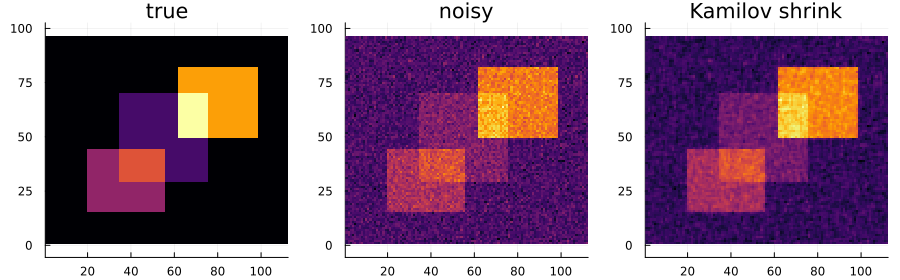

In [17]:
# 2D method test: Kamilov transform shrinkage

Random.seed!(2)
M, N = 96, 112
xtrue_2d = zeros(Float64, M, N)
xtrue_2d[16:44, 20:55] .= 1.5
xtrue_2d[50:82, 62:98] .= 3.0
xtrue_2d[30:70, 35:75] .+= 0.8
noise_σ = 0.35
y_2d = xtrue_2d .+ noise_σ .* randn(M, N)
λ_2d = 0.18

x_kamilov_2d = similar(y_2d)
av = similar(y_2d)
dv = similar(y_2d)
ah = similar(y_2d)
dh = similar(y_2d)

λ_grid = 10 .^ range(-2, 10, length=20)
best_λ = NaN
best_rmse = Inf
for λ in λ_grid
    tv2d_kamilov_denoise!(x_kamilov_2d, y_2d, λ, av, dv, ah, dh)
    println(λ, "  RMSE=", rmse(x_kamilov_2d, xtrue_2d), "  TV=", tv2_iso_value(x_kamilov_2d))
    r = rmse(x_kamilov_2d, xtrue_2d)
    if r < best_rmse
        best_rmse = r
        best_λ = λ
    end
end

tv2d_kamilov_denoise!(x_kamilov_2d, y_2d, best_λ, av, dv, ah, dh)

println("2D denoising quality")
println("noisy           RMSE = ", rmse(y_2d, xtrue_2d), "  isotropic TV = ", tv2_iso_value(y_2d))
println("Kamilov shrink  RMSE = ", rmse(x_kamilov_2d, xtrue_2d), "  isotropic TV = ", tv2_iso_value(x_kamilov_2d))

println("\n2D operator checks")
W_kamilov_2d!(av, dv, ah, dh, y_2d)
x_recon_2d = similar(y_2d)
WT_kamilov_2d!(x_recon_2d, av, dv, ah, dh)
println("in-place W'W relative reconstruction error = ", norm(x_recon_2d - y_2d) / norm(y_2d))

println("\n2D benchmark median time and memory")
for sz in [(64, 64), (128, 128), (256, 256)]
    Random.seed!(prod(sz))
    y = randn(sz...)
    x = similar(y)
    av = similar(y)
    dv = similar(y)
    ah = similar(y)
    dh = similar(y)

    b_workspace = @benchmark tv2d_kamilov_denoise!($x, $y, $best_λ, $av, $dv, $ah, $dh)
    b_allocating = @benchmark tv2d_kamilov_denoise($y, $best_λ)

    println("\nsize = $sz")
    println("Kamilov 2D !         ", median(b_workspace).time / 1e6, " ms, ", median(b_workspace).memory, " bytes")
    println("Kamilov 2D allocating ", median(b_allocating).time / 1e6, " ms, ", median(b_allocating).memory, " bytes")
end

p1 = heatmap(xtrue_2d, title="true", aspect_ratio=:equal, colorbar=false)
p2 = heatmap(y_2d, title="noisy", aspect_ratio=:equal, colorbar=false)
p3 = heatmap(x_kamilov_2d, title="Kamilov shrink", aspect_ratio=:equal, colorbar=false)
plot(p1, p2, p3, layout=(1, 3), size=(900, 280))